In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

In [2]:
base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

In [9]:
wrap_f

In [12]:
wrap_f['map/matchup/repeat/player/time'].keys()

<KeysViewHDF5 ['action', 'direction', 'events', 'health', 'lstm', 'policy_fos', 'policy_j', 'policy_llr', 'policy_lud', 'policy_mbf', 'policy_slr', 'position', 'post_lstm', 'pre_lstm', 'ranged', 'reward', 'value', 'velocity']>

In [68]:
map_id=slice(None)
matchup_id=slice(None)
repeat_id=slice(None)
player_id=slice(None) 
a=wrap_f['map/matchup/repeat/player/time/health'][map_id,matchup_id,repeat_id,player_id]
# matchups 0, 34, 49, 54 = AA, BB, CC, DD

In [69]:
a.shape

(1, 55, 8, 4, 4501, 1)

ValueError: x and y can be no greater than 2D, but have shapes (4501,) and (4501, 4, 8, 55)

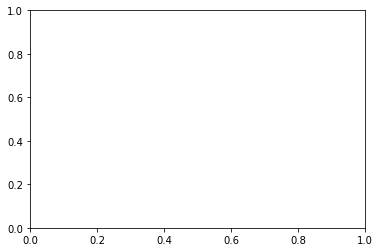

In [47]:
plt.plot(a.squeeze().T)

In [27]:
wrap_f['map/matchup/repeat/player'].keys()

<KeysViewHDF5 ['agent_id', 'color_id', 'slot_id', 'time']>

In [26]:
wrap_f['map/matchup/repeat'].keys()

<KeysViewHDF5 ['blue_team_score', 'player', 'red_team_score', 'time']>

In [29]:
wrap_f['map'].keys()

<KeysViewHDF5 ['blue_base_position', 'map_colors', 'map_features', 'map_id', 'matchup', 'red_base_position']>

In [33]:
wrap_f['map/matchup/repeat/time'].keys()

<KeysViewHDF5 ['blue_flag_position', 'blue_flag_status', 'blue_team_score', 'red_flag_position', 'red_flag_status', 'red_team_score']>

In [35]:
wrap_f['map/matchup/repeat/player/agent_id']

<HDF5 dataset "agent_id": shape (1, 55, 8, 4, 1), type "|u1">

(4, 4501, 512)


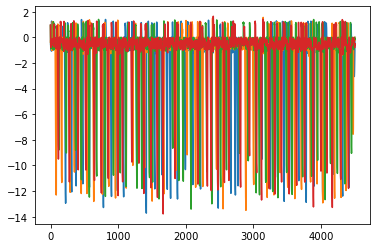

In [40]:
a=wrap_f['map/matchup/repeat/player/time/lstm'][map_id,matchup_id,repeat_id,player_id]
print(a.shape)
plt.plot(a[:,:,0].T)

(4, 4501, 1)


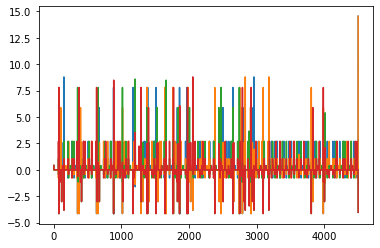

In [41]:
a=wrap_f['map/matchup/repeat/player/time/reward'][map_id,matchup_id,repeat_id,player_id]
print(a.shape)
plt.plot(a.squeeze().T)

(4, 4501, 3)


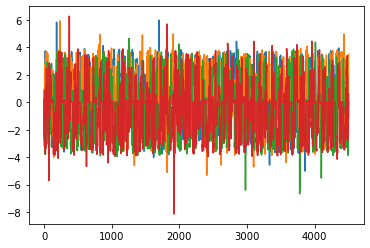

In [44]:
a=wrap_f['map/matchup/repeat/player/time/velocity'][map_id,matchup_id,repeat_id,player_id]
print(a.shape)
plt.plot(a[:,:,0].T)

In [4]:
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

In [49]:
lstmPCs.shape

(4, 8, 4, 4501, 100)

In [5]:
lstmPCsCom = np.load('results/lstms_tanh-z_pca-k100_reg-com.npy')

In [51]:
lstmPCsCom.shape

(4, 8, 4, 4501, 100)

In [52]:
#look at PCs 2, 7, 9, 23, 24 (0-indexed)

In [3]:
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc

In [4]:
a=np.random.randn(100)
b=np.random.randn(100)
c=a+np.random.randn(100)*0.1

In [63]:
ps=phase_synchrony(a,c)

In [57]:
ps.shape

(100,)

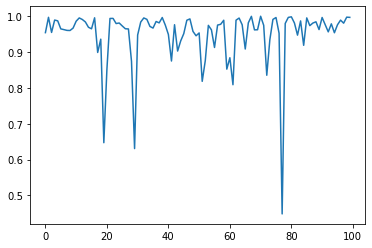

In [64]:
plt.plot(ps)

In [10]:
#recompute and save the isps analysis with comreg PCs
matchup,repeat=0,0
pc=0
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)

(6, 4501)


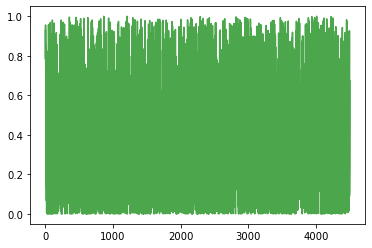

In [20]:
print(ispsComReg.shape)
plt.plot(ispsComReg[0], c='green', alpha=.7)

(6, 4501)


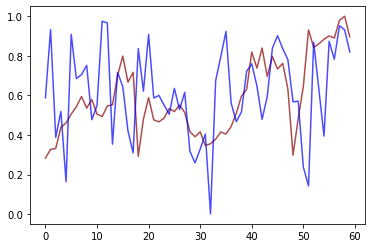

In [52]:
lstm_pc_isps = isps(lstmPCs[matchup, repeat, ..., 9].T) ###
print(lstm_pc_isps.shape)
lstm_pc_isps_com = isps(lstmPCsCom[matchup, repeat, ..., 9].T) ###
plt.plot(lstm_pc_isps[0,160:220], c='darkred', alpha=.7)
plt.plot(lstm_pc_isps_com[0,160:220], c='blue', alpha=.7)

In [53]:
from scipy.stats import pearsonr

pearsonr(lstm_pc_isps[0], lstm_pc_isps_com[0])

(0.20704080403681197, 9.025442210960226e-45)

(4, 4501)


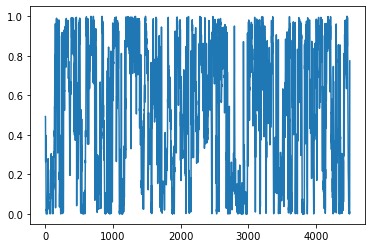

In [40]:
print(lstmPCsCom[matchup, repeat, ..., pc].shape)
ps=phase_synchrony(lstmPCs[matchup, repeat, ..., pc][0],lstmPCs[matchup, repeat, ..., pc][1])
plt.plot(ps)

(4, 4501)


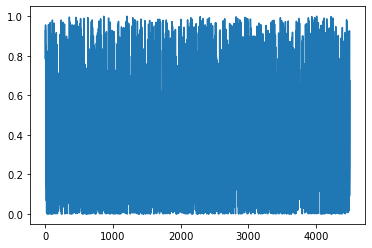

In [24]:
print(lstmPCsCom[matchup, repeat, ..., pc].shape)
ps=phase_synchrony(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
plt.plot(ps)

Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows


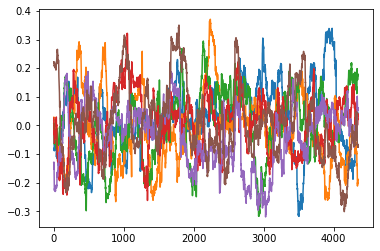

In [38]:
from coupling_metrics import window_isc
ps=window_isc(lstmPCsCom[matchup, repeat, ..., pc].T)
plt.plot(ps)

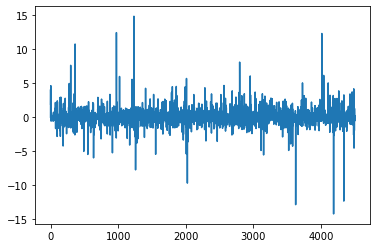

In [36]:
from coupling_metrics import iscf
ps=iscf(lstmPCsCom[matchup, repeat, ..., pc].T)
plt.plot(ps[0])

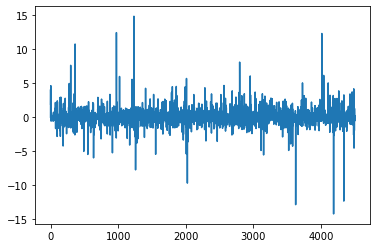

In [41]:
from coupling_metrics import cofluctuation
ps=cofluctuation(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
plt.plot(ps)

Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows


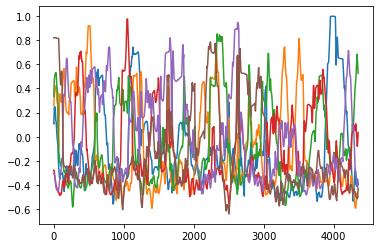

In [42]:
ps=window_isc(lstmPCs[matchup, repeat, ..., pc].T)
plt.plot(ps)

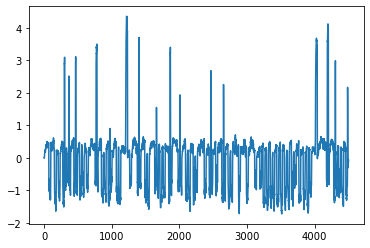

In [43]:
ps=iscf(lstmPCs[matchup, repeat, ..., pc].T)
plt.plot(ps[0])

Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows


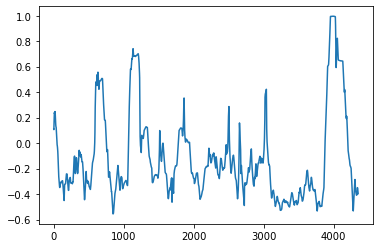

In [51]:
ps=window_isc(lstmPCs[matchup, repeat, ..., pc].T)
plt.plot(ps.T[0])

In [52]:
pc=2
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)

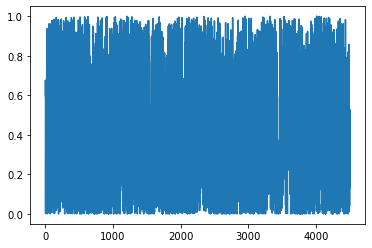

In [61]:
pc=1
ps=phase_synchrony(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
plt.plot(ispsComReg[0])

In [55]:
#look at PCs 2, 7, 9, 23, 24 (0-indexed)
# matchup, repeat, agent, time, pc

lstmPCsCom = np.load('results/lstms_tanh-z_pca-k100_reg-com.npy')
print(lstmPCsCom.shape)

matchup,repeat,pc=0,0,0
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
#plt.plot(ispsComReg[0][:100], c='green', alpha=.7)

map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action
#action', 'direction', 'events', 'health', 'lstm', 'policy_fos', 'policy_j', 'policy_llr', 'policy_lud', 'policy_mbf', 'policy_slr', 'position', 'post_lstm', 'pre_lstm', 'ranged', 'reward', 'value', 'velocity
#plt.plot(abs(a[matchup, repeat, 0, ..., 5][:100] - a[matchup, repeat, 1, ..., 5][:100])/250, c='red', alpha=.7)

(4, 8, 4, 4501, 100)
(6, 4501)


(6, 4501)


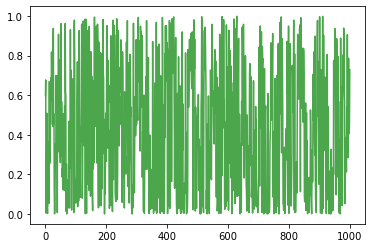

In [35]:
matchup,repeat,pc=0,0,2
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
plt.plot(ispsComReg[0,:1000], c='green', alpha=.7)
#plt.plot(ispsComReg[1,:100], c='red', alpha=.7)

(6, 4501)


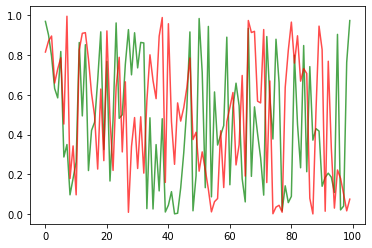

In [24]:
matchup,repeat,pc=0,0,7
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
plt.plot(ispsComReg[0][:100], c='green', alpha=.7)
plt.plot(ispsComReg[1,:100], c='red', alpha=.7)

map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action

(6, 4501)


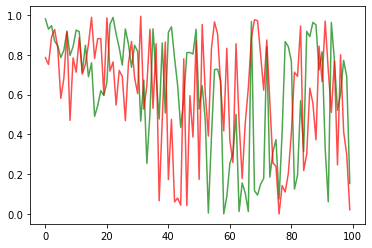

In [29]:
matchup,repeat,pc=0,0,9
ispsComReg = isps(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
plt.plot(ispsComReg[0][:100], c='green', alpha=.7)
plt.plot(ispsComReg[1,:100], c='red', alpha=.7)

map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action
#plt.plot(abs(a[matchup, repeat, 0, ..., 3][:100] - a[matchup, repeat, 1, ..., 3][:100])/250, c='red', alpha=.7)

(6, 4501)


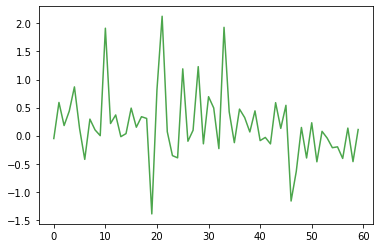

In [56]:
matchup,repeat,pc=0,0,23
ispsComReg = iscf(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
plt.plot(ispsComReg[0][100:160], c='green', alpha=.7)

map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action

(6, 4501)


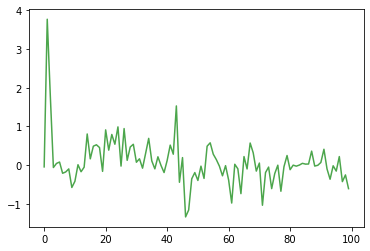

In [58]:
matchup,repeat,pc=0,0,24
ispsComReg = iscf(lstmPCsCom[matchup, repeat, ..., pc].T)
print(ispsComReg.shape)
plt.plot(ispsComReg[0][:100], c='green', alpha=.7)

map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action

(55, 8, 4, 4501, 6)


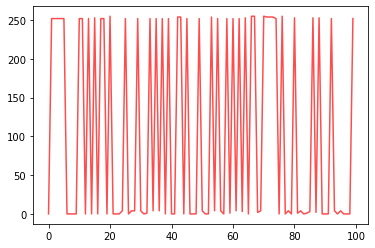

In [41]:
map_id=0
a=wrap_f['map/matchup/repeat/player/time/action'][map_id] #action
print(a.shape)
plt.plot(abs(a[matchup, repeat, 0, ..., 0][:100] - a[matchup, repeat, 1, ..., 0][:100]), c='red', alpha=.7)
#action', 'direction', 'events', 'health', 'lstm', 'policy_fos', 'policy_j', 'policy_llr', 'policy_lud', 'policy_mbf', 'policy_slr', 'position', 'post_lstm', 'pre_lstm', 'ranged', 'reward', 'value', 'velocity
#plt.plot(abs(a[matchup, repeat, 0, ..., 5][:100] - a[matchup, repeat, 1, ..., 5][:100])/250, c='red', alpha=.7)

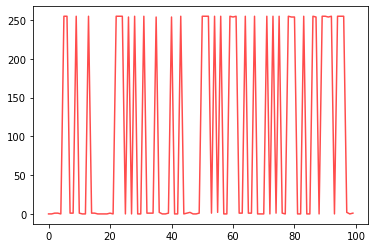

In [42]:
plt.plot(abs(a[matchup, repeat, 0, ..., 1][:100] - a[matchup, repeat, 1, ..., 1][:100]), c='red', alpha=.7)

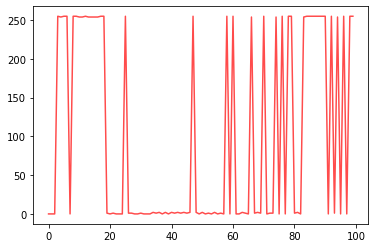

In [43]:
plt.plot(abs(a[matchup, repeat, 0, ..., 2][:100] - a[matchup, repeat, 1, ..., 2][:100]), c='red', alpha=.7)

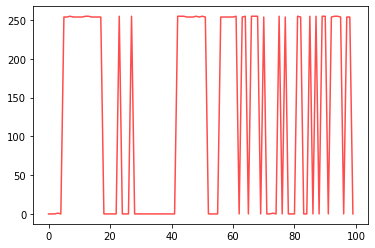

In [44]:
plt.plot(abs(a[matchup, repeat, 0, ..., 3][:100] - a[matchup, repeat, 1, ..., 3][:100]), c='red', alpha=.7)

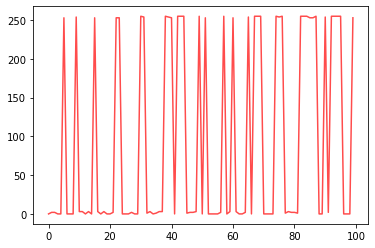

In [45]:
plt.plot(abs(a[matchup, repeat, 0, ..., 4][:100] - a[matchup, repeat, 1, ..., 4][:100]), c='red', alpha=.7)

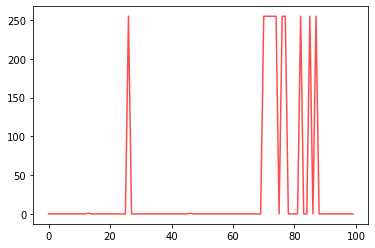

In [46]:
plt.plot(abs(a[matchup, repeat, 0, ..., 5][:100] - a[matchup, repeat, 1, ..., 5][:100]), c='red', alpha=.7)

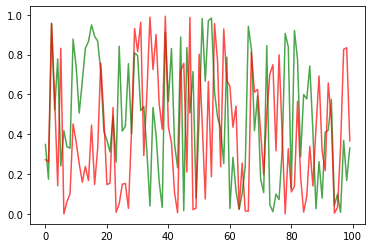

In [34]:
plt.plot(ispsComReg[2,:100], c='green', alpha=.7)
plt.plot(ispsComReg[3,:100], c='red', alpha=.7)

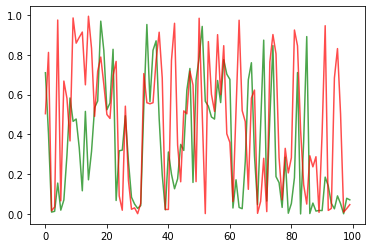

In [33]:
plt.plot(ispsComReg[4,:100], c='green', alpha=.7)
plt.plot(ispsComReg[5,:100], c='red', alpha=.7)

In [78]:
wrap_f['map/matchup/repeat/player/time/player_from_teammate_xy_distance'][0,0,0,0]

array([[ 2.236],
       [ 2.223],
       [ 2.133],
       ...,
       [10.61 ],
       [10.414],
       [10.12 ]], dtype=float16)

In [147]:
print(lstmPCsCom.shape)
avgs=[]
for pc in range(len(lstmPCsCom[matchup,repeat,0,0])):
    sm=0
    for matchup in range(len(lstmPCsCom)):
        for repeat in range(len(lstmPCsCom[matchup])):
            ps=phase_synchrony(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
            cf=cofluctuation(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
            sm+=pearsonr(ps, cf)[0]**2
    avgs.append(sm/(4*8))
    #print(sm/(4*8))
print(avgs)
print(np.sum(np.array(avgs))/100)

(4, 8, 4, 4501, 100)
[0.16401603947882853, 0.26404249779901834, 0.2531621733877294, 0.25188825818106453, 0.25847976132818734, 0.25878904035440353, 0.2624508800440538, 0.2552005296690765, 0.2624863235821007, 0.25697905482014677, 0.25087516099426105, 0.2539014694492423, 0.2663622566775994, 0.249128556578101, 0.24212332405962847, 0.2633413088115647, 0.24929940075302914, 0.260271021421176, 0.26325516643977115, 0.24909718042374385, 0.2596924849433406, 0.25167070041858025, 0.2540118173438044, 0.2533485722477639, 0.19295223999024932, 0.2012406179819952, 0.22990487153268974, 0.19976620685106777, 0.25701649522637404, 0.25313219947558213, 0.24783023515079844, 0.22130582297061238, 0.2505891708294488, 0.20997838114920514, 0.24014913674465543, 0.25010332006686176, 0.24225532787257403, 0.19651619677460846, 0.21086566654773262, 0.23304368521713217, 0.22937702250067823, 0.22504490305081326, 0.2556950710991017, 0.24502346131697952, 0.25935362069814083, 0.212145254641187, 0.22756805120106804, 0.24414907

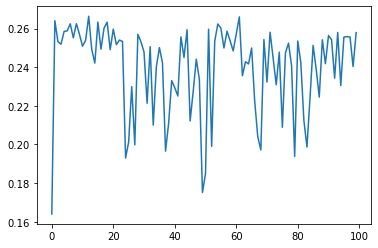

In [148]:
plt.plot(avgs)

In [86]:
wrap_f['map/matchup/repeat/player/time/player_from_teammate_xy_distance'][0,0,0].squeeze().shape

(4, 4501)

(4, 8, 4, 4501, 100)
[-0.00981959592370568, -0.0214429858677607, -0.005536451061892734, -0.014702353064071078, -0.009242247874772286, -0.0021025092724802426, -0.004309123739102059, -0.0050695692323329085, -0.006893285704906556, -0.012107948087680646, -0.005545283772142268, -0.010485798937678528, -0.01783798415523398, -0.0052612556426007, -0.011594359146007985, -0.003391750701480924, -0.006047503048101078, 0.001018238190207269, -0.0030101130059464708, -0.01083782534851209, -0.011519020090278803, -0.01048006088277485, -0.008889504493416505, -0.003574756788144011, -0.006151350125502728, -0.02134330990320432, -0.004546943902686319, -0.009264809638575806, -0.024463562887004468, -0.003990977656211823, -0.010625244300769929, -0.013788618972373951, -0.0052713586913943474, -0.027087969526295504, -0.01024784640446894, -0.002555373219839902, -0.013669025739701777, -0.0045980022208629715, -0.005176044426280643, -0.006280178067159213, -0.007808618084092548, -0.009522894503287943, -0.015370826311507

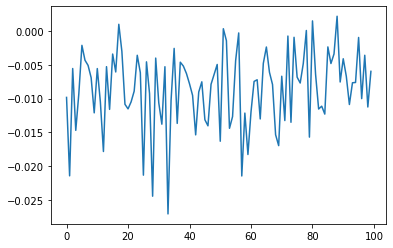

In [150]:
print(lstmPCsCom.shape)
avgs=[]
mp=0
for pc in range(len(lstmPCsCom[matchup,repeat,0,0])):
    sm=0
    for matchup in range(len(lstmPCsCom)):
        for repeat in range(len(lstmPCsCom[matchup])):
            ps=phase_synchrony(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1])
            dist=wrap_f['map/matchup/repeat/player/time/player_from_teammate_xy_distance'][mp, matchup, repeat].squeeze()[0]
            sm+=pearsonr(ps, dist)[0]
    avgs.append(sm/(4*8))
    #print(sm/(4*8))
print(avgs)
plt.plot(avgs)
#print(np.sum(np.array(avgs))/100)

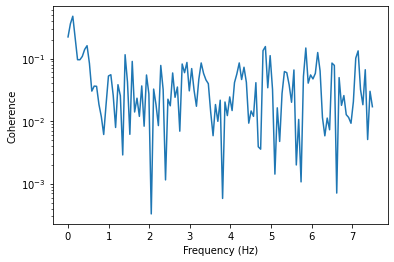

In [184]:
import scipy
#look at PCs 2, 7, 9, 23, 24 (0-indexed)

matchup,repeat,pc=0,2,7
f, Cxy = scipy.signal.coherence(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1],fs=15)
plt.semilogy(f, Cxy)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.show()

(4, 4501)
(129,)


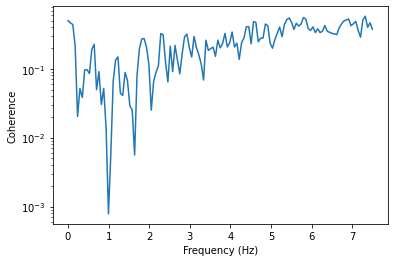

In [183]:
#look at PCs 2, 7, 9, 23, 24 (0-indexed)

matchup,repeat,pc=0,1,7
print(lstmPCs[matchup, repeat, ..., pc].shape)
f, Cxy = scipy.signal.coherence(lstmPCs[matchup, repeat, ..., pc][0],lstmPCs[matchup, repeat, ..., pc][1], fs=15, detrend=False)
print(Cxy.shape)
plt.semilogy(f, Cxy)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.show()

(4, 4501)
(129,)


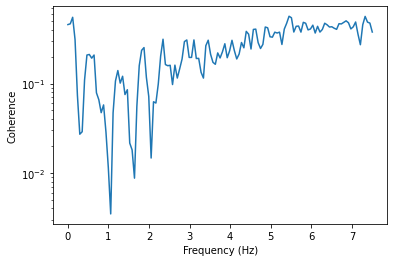

In [ ]:
#look at PCs 2, 7, 9, 23, 24 (0-indexed)
from itertools import combinations

coopIds, compIds = [0,5],[1,2,3,4]
matchup,repeat,pc=0,1,7
print(lstmPCs[matchup, repeat, ..., pc].shape)
pairwise_coh=[]
for pair in combinations(np.arange(4),2):
    f, Cxy = scipy.signal.coherence(lstmPCs[matchup, repeat, ..., pc][pair[0]],lstmPCs[matchup, repeat, ..., pc][pair[1]], fs=15, detrend=False)
    pairwise_coh.append(Cxy)
print(Cxy.shape)
plt.semilogy(f, pairwise_coh[0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.show()

In [114]:
import pycwt

print(pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1],.25))

NOTE: WCT significance loaded from cache.

(array([[0.62027776, 0.51829136, 0.39170808, ..., 0.65877653, 0.78151441,
        0.85772434],
       [0.64629349, 0.54840456, 0.42013125, ..., 0.60009703, 0.72523465,
        0.80624072],
       [0.6672538 , 0.57508849, 0.45074759, ..., 0.55601195, 0.67725233,
        0.75752656],
       ...,
       [0.97195342, 0.97195304, 0.97195267, ..., 0.97121939, 0.97121985,
        0.97122032],
       [0.97911515, 0.97911478, 0.97911441, ..., 0.97847642, 0.97847686,
        0.97847731],
       [0.98777211, 0.98777187, 0.98777164, ..., 0.98747867, 0.98747894,
        0.98747921]]), array([[-1.67095902, -1.07978613, -0.16988717, ..., -0.67055789,
        -0.62024212, -0.51320914],
       [-1.45060758, -0.9221259 , -0.23683367, ..., -0.59850503,
        -0.58420623, -0.49065924],
       [-1.26740283, -0.82742055, -0.30043433, ..., -0.56230294,
        -0.56491892, -0.47695835],
       ...,
       [-0.02918484, -0.02918491, -0.02918499, ..., -0.03671943,
 

In [128]:
avgs=[]
for pc in range(len(lstmPCs[matchup,repeat,0,0])):
    sm=0
    for matchup in range(len(lstmPCs)):
        for repeat in range(len(lstmPCs[matchup])):
            ps=phase_synchrony(lstmPCs[matchup, repeat, ..., pc][0],lstmPCs[matchup, repeat, ..., pc][1])
            cf=cofluctuation(lstmPCs[matchup, repeat, ..., pc][0],lstmPCs[matchup, repeat, ..., pc][1])
            sm+=pearsonr(ps, cf)[0]**2
    avgs.append(sm/(4*8))
    #print(sm/(4*8))
print(np.sum(np.array(avgs))/100)

0.23043034515544483


In [129]:
avgs=[]
mp=0
for pc in range(len(lstmPCs[matchup,repeat,0,0])):
    sm=0
    for matchup in range(len(lstmPCs)):
        for repeat in range(len(lstmPCs[matchup])):
            ps=phase_synchrony(lstmPCs[matchup, repeat, ..., pc][0],lstmPCs[matchup, repeat, ..., pc][1])
            dist=wrap_f['map/matchup/repeat/player/time/player_from_teammate_xy_distance'][mp, matchup, repeat].squeeze()[0]
            sm+=pearsonr(ps, dist)[0]**2
    avgs.append(sm/(4*8))
    #print(sm/(4*8))
print(np.sum(np.array(avgs))/100)

0.004225377329986389


(129,)


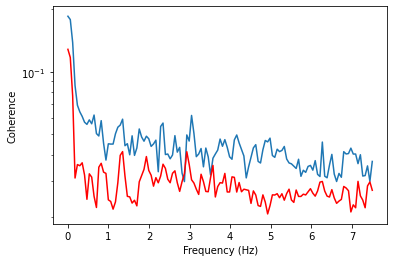

In [6]:
import scipy
from itertools import combinations

coopIds, compIds = [0,5],[1,2,3,4]
#matchup,repeat,pc=0,1,7
pc=2
pairwise_coh=[]

avgs=[]
for pair in combinations(np.arange(4),2):
    sm=0
    for matchup in range(len(lstmPCsCom)):
        for repeat in range(len(lstmPCsCom[matchup])):
            #for pc in range(len(lstmPCs[matchup,repeat,0,0])):
            f, Cxy = scipy.signal.coherence(lstmPCs[matchup, repeat, ..., pc][pair[0]],lstmPCs[matchup, repeat, ..., pc][pair[1]], fs=15, detrend=False)
            sm+=Cxy
    pairwise_coh.append(sm/(4*8))
print(Cxy.shape)
plt.semilogy(f, (pairwise_coh[0]+pairwise_coh[5])/2)
plt.semilogy(f, np.sum(pairwise_coh[1:4], axis=0)/4, color='red')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
#plt.title('Cooperative pairs average')
plt.show()

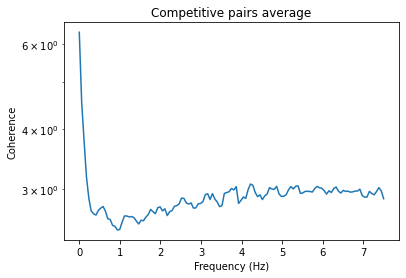

In [20]:
plt.semilogy(f, np.sum(pairwise_coh[1:4], axis=0)/4)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.title('Competitive pairs average')
plt.show()

NOTE: WCT significance loaded from cache.

(51, 4501)
(51,)
[7.5        7.07905735 6.68174039 6.30672311 5.95275394 5.61865154
 5.30330086 5.00564945 4.72470394 4.45952668 4.20923268 3.9729866
 3.75       3.53952867 3.34087019 3.15336156 2.97637697 2.80932577
 2.65165043 2.50282473 2.36235197 2.22976334 2.10461634 1.9864933
 1.875      1.76976434 1.6704351  1.57668078 1.48818849 1.40466288
 1.32582521 1.25141236 1.18117598 1.11488167 1.05230817 0.99324665
 0.9375     0.88488217 0.83521755 0.78834039 0.74409424 0.70233144
 0.66291261 0.62570618 0.59058799 0.55744084 0.52615409 0.49662333
 0.46875    0.44244108 0.41760877]


/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


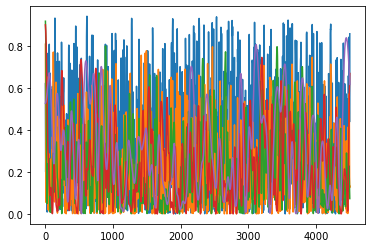

In [48]:
import pycwt

#coherence, angle, cone of influence, frequency, significance
#cone of influence is a vector of N points containing the maximum Fourier period of useful information 
#   at that particular time. Periods greater than those are subject to edge effects.
#freq is vector of Fourier frequencies (in 1 / time units) that corresponds to the wavelet scales
#wct_significance calculates WCT significance using Monte Carlo simulations with 95% confidence.
pc=2
WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1],1/15,J=50)#0.25
print(WCT.shape)
print(freq.shape)
print(freq)
plt.plot(WCT[0])
plt.plot(WCT[10])
plt.plot(WCT[25])
plt.plot(WCT[35])
plt.plot(WCT[50])
#plt.plot(WCT[80])
#plt.plot(WCT[100])
#plt.plot(WCT[120])

NOTE: WCT significance loaded from cache.

(135, 4501)
(135,)
[7.50000000e+00 7.07905735e+00 6.68174039e+00 6.30672311e+00
 5.95275394e+00 5.61865154e+00 5.30330086e+00 5.00564945e+00
 4.72470394e+00 4.45952668e+00 4.20923268e+00 3.97298660e+00
 3.75000000e+00 3.53952867e+00 3.34087019e+00 3.15336156e+00
 2.97637697e+00 2.80932577e+00 2.65165043e+00 2.50282473e+00
 2.36235197e+00 2.22976334e+00 2.10461634e+00 1.98649330e+00
 1.87500000e+00 1.76976434e+00 1.67043510e+00 1.57668078e+00
 1.48818849e+00 1.40466288e+00 1.32582521e+00 1.25141236e+00
 1.18117598e+00 1.11488167e+00 1.05230817e+00 9.93246651e-01
 9.37500000e-01 8.84882168e-01 8.35217548e-01 7.88340389e-01
 7.44094243e-01 7.02331442e-01 6.62912607e-01 6.25706182e-01
 5.90587992e-01 5.57440835e-01 5.26154085e-01 4.96623325e-01
 4.68750000e-01 4.42441084e-01 4.17608774e-01 3.94170195e-01
 3.72047122e-01 3.51165721e-01 3.31456304e-01 3.12853091e-01
 2.95293996e-01 2.78720418e-01 2.63077043e-01 2.48311663e-01
 2.34375000e-01 2.21220

/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


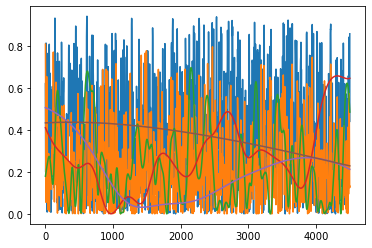

In [49]:
WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1],1/15)#0.25
print(WCT.shape)
print(freq.shape)
print(freq)
plt.plot(WCT[0])
plt.plot(WCT[10])
plt.plot(WCT[50])
plt.plot(WCT[80])
plt.plot(WCT[100])
plt.plot(WCT[120])

0.4176087741282842


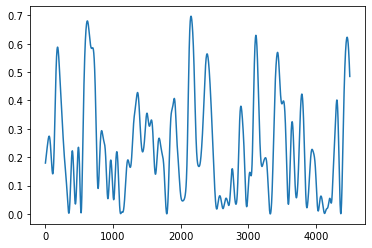

In [51]:
plt.plot(WCT[50])
print(freq[50])

In [58]:
pc=2

WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1],1/4, dj=1/3, s0=-1, J=-1)
print(WCT.shape)
print(freq.shape)
#print(freq)
#plt.plot(WCT[0])
#plt.plot(WCT[10])
#plt.plot(WCT[50])
#plt.plot(WCT[80])
#plt.plot(WCT[100])
#plt.plot(WCT[120])

Calculating wavelet coherence significance


100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [27:07<00:00,  5.42s/it]

(35, 4501)
(35,)


[2.00000000e+00 1.58740105e+00 1.25992105e+00 1.00000000e+00
 7.93700526e-01 6.29960525e-01 5.00000000e-01 3.96850263e-01
 3.14980262e-01 2.50000000e-01 1.98425131e-01 1.57490131e-01
 1.25000000e-01 9.92125657e-02 7.87450656e-02 6.25000000e-02
 4.96062829e-02 3.93725328e-02 3.12500000e-02 2.48031414e-02
 1.96862664e-02 1.56250000e-02 1.24015707e-02 9.84313320e-03
 7.81250000e-03 6.20078536e-03 4.92156660e-03 3.90625000e-03
 3.10039268e-03 2.46078330e-03 1.95312500e-03 1.55019634e-03
 1.23039165e-03 9.76562500e-04 7.75098170e-04]


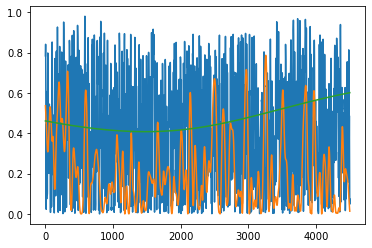

In [60]:
print(freq)
plt.plot(WCT[0])
plt.plot(WCT[10])
plt.plot(WCT[30])

/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


Calculating wavelet coherence significance


100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [00:43<00:00,  6.83it/s]


(21, 4501)
(21,)
[7.5        5.95275394 4.72470394 3.75       2.97637697 2.36235197
 1.875      1.48818849 1.18117598 0.9375     0.74409424 0.59058799
 0.46875    0.37204712 0.295294   0.234375   0.18602356 0.147647
 0.1171875  0.09301178 0.0738235 ]


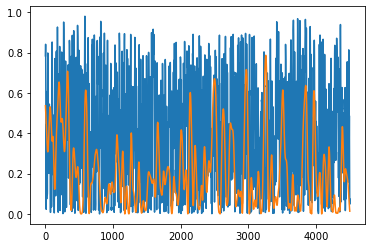

In [69]:
pc=2

WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1], 1/15, dj=1/3, J=20)
print(WCT.shape)
print(freq.shape)
print(freq)

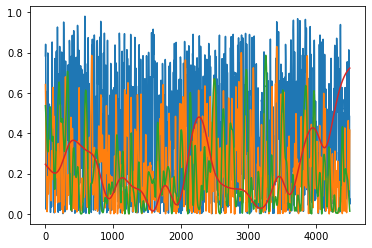

In [70]:
plt.plot(WCT[0])
plt.plot(WCT[5])
plt.plot(WCT[10])
plt.plot(WCT[20])

In [71]:
print(sig.shape)
print(sig)

(21,)
[0.85906355 0.74495153 0.63740312 0.57503618 0.57401818 0.57891964
 0.57579355 0.57568103 0.57872    0.58255137 0.58294972 0.58261071
 0.58025434 0.58045779 0.57821678 0.58465845 0.58344172 0.58507477
 0.59623707 0.58439669        nan]


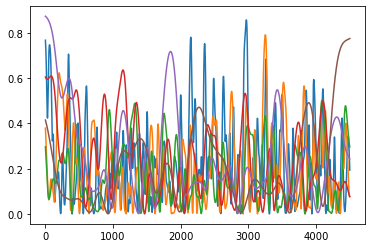

In [75]:
plt.plot(WCT[-12::2].T)

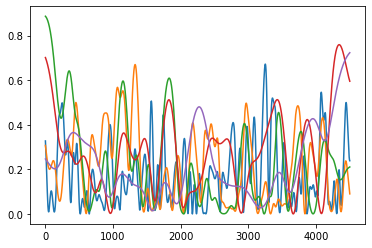

In [76]:
plt.plot(WCT[-9::2].T)

/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT s

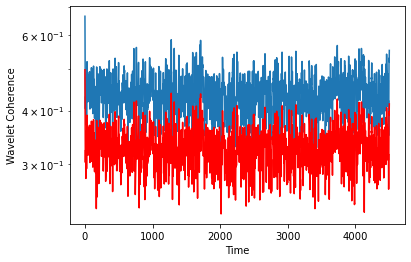

In [19]:
import pycwt
import scipy
from itertools import combinations

coopIds, compIds = [0,5],[1,2,3,4]
#matchup,repeat,pc=0,1,7
pc=2
wCoh=[]

avgs=[]
for pair in combinations(np.arange(4),2):
    sm=0
    for matchup in range(len(lstmPCsCom)):
        for repeat in range(len(lstmPCsCom[matchup])):
            #for pc in range(len(lstmPCs[matchup,repeat,0,0])):
            WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1], 1/15, dj=1/3, J=20)
            sm+=WCT[0]###
    wCoh.append(sm/(4*8))
print(wCoh[0].shape)
plt.semilogy(range(4501), (wCoh[0]+wCoh[5])/2)
plt.semilogy(range(4501), np.sum(wCoh[1:4], axis=0)/4, color='red')
plt.xlabel('Time')
plt.ylabel('Wavelet Coherence')
#plt.title('Cooperative pairs average')
plt.show()

/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT s

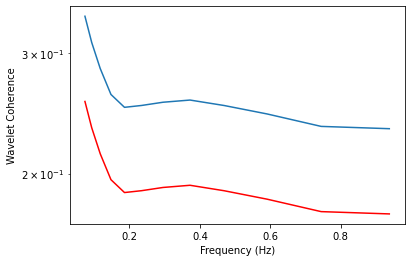

In [22]:
import pycwt
import scipy
from itertools import combinations

coopIds, compIds = [0,5],[1,2,3,4]
#matchup,repeat,pc=0,1,7
pc=2
wCoh=[]

avgs=[]
for pair in combinations(np.arange(4),2):
    sm=0
    for matchup in range(len(lstmPCsCom)):
        for repeat in range(len(lstmPCsCom[matchup])):
            #for pc in range(len(lstmPCs[matchup,repeat,0,0])):
            WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1], 1/15, dj=1/3, J=20);
            sm+=np.average(WCT,axis=1)
    wCoh.append(sm/(4*8))
print(wCoh[0].shape)
print(freq)
plt.semilogy(freq[9:21], ((wCoh[0]+wCoh[5])/2)[9:21])
plt.semilogy(freq[9:21], (np.sum(wCoh[1:4], axis=0)/4)[9:21], color='red')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Wavelet Coherence')
#plt.title('Cooperative pairs average')
plt.show()

/usr/people/vgraf/miniconda3/envs/ctf/lib/python3.7/site-packages/pycwt/wavelet.py:562: RuntimeWarning: invalid value encountered in arctanh
  aa = np.round(np.arctanh(np.array([al1, al2]) * 4))


NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

(21, 4501)
[7.5        5.95275394 4.72470394 3.75       2.97637697 2.36235197
 1.875      1.48818849 1.18117598 0.9375     0.74409424 0.59058799
 0.46875    0.37204712 0.295294   0.234375   0.18602356 0.147647
 0.1171875  0.09301178 0.0738235 ]


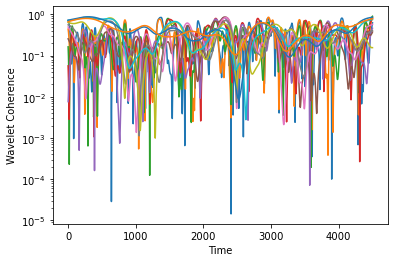

In [29]:
import pycwt
import scipy
from itertools import combinations

coopIds, compIds = [0,5],[1,2,3,4]
#matchup,repeat,pc=0,1,7
pc=2
wCoh=[]

avgs=[]
for pair in combinations(np.arange(4),2):
    sm=0
    matchup,repeat=0,0
    WCT, aWCT, coi, freq, sig = pycwt.wct(lstmPCsCom[matchup, repeat, ..., pc][0],lstmPCsCom[matchup, repeat, ..., pc][1], 1/15, dj=1/3, J=20);
    sm+=WCT
    wCoh.append(sm)
print(wCoh[0].shape)
print(freq)
plt.semilogy((wCoh[0])[9:21].T)
#plt.semilogy((np.sum(wCoh[1:4], axis=0)/4)[9:21], color='red')
plt.xlabel('Time')
plt.ylabel('Wavelet Coherence')
#plt.title('Cooperative pairs average')
plt.show()